Step 1 - Import

In [1]:
import requests
import base64
from PIL import Image
import matplotlib.pyplot as plt
import json

Step 2 - Display Image

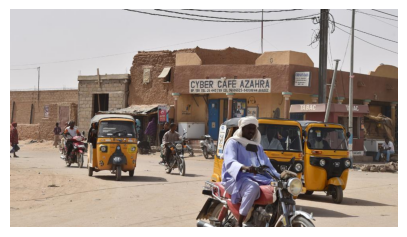

In [2]:
img_path = "../img/sample3.jpg"

img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

Step 3 - Function Kirim Image ke LLM

In [3]:
def ask_qwen_image(image_path, prompt):
    with open(image_path,"rb") as f:
        image_base64 = base64.b64encode(f.read()).decode()
    
    payload={
        "model": "qwen3.5:4b",
        "prompt": prompt,
        "images": [image_base64],
        "stream": False,
        "think": False,
        "options":{
            # "num_predict":100,
            "temperature":0.7
        }
    }
    response=requests.post(
        "http://localhost:11434/api/generate",
        json=payload
    )
    return response.json()["response"]

Experiment 1 - Captioning

In [24]:
prompt = """Deskripsikan gambar ini."""

result = ask_qwen_image(img_path, prompt)
print(result)

Gambar ini menampilkan pemandangan jalanan di sebuah kota atau desa yang tampak kaku, mungkin terletak di kawasan Afrika Sub-Sahara — seperti Sudan Selatan atau Namibia berdasarkan gaya bangunan dan pakaian penduduknya.

**Elemen utama dalam gambar:**

1. **Lokasi & Suasana**:  
   Jalannya berpasir dengan sedikit lalu lintas kendaraan roda dua dan tiga. Langit cerah namun tanpa awan, memberikan kesan panas dan kering khas daerah gurun atau semi-gurun. Bangunan-b


Experiment 2 - Scene Understanding

In [25]:
prompt="""
Analisis:
1. Objek Apa aja yang ada
2. Kejadian apa yang sedang berlangsung
3. Deskripsikan Lingkungan pada gambar
4. Simpulkan Sesuai konteks pada gambar
"""
print(ask_qwen_image(img_path ,prompt))

Berikut adalah analisis lengkap terhadap gambar tersebut, sesuai permintaan Anda:

---

### 1. **Objek yang Ada dalam Gambar**

- **Otomotil / Kendaraan Umum**:
  - Tiga *moto-taksi* (angkot) berwarna kuning dan hitam — salah satunya di depan tengah dengan sopir memakai jubah putih tradisional.
  - Beberapa sepeda motor lainnya, termasuk satu merah muda sedang melintas dari kiri ke kanan.
  - Sepeda motor lain yang


Experiment 3 - Reasoning

In [26]:
prompt="""
Perhatikan dengan saksama.
Jelaskan:
1. apa yang mungkin terjadi sebelumnya
2. apa yang mungkin terjadi selanjutnya
3. mengapa Anda berpikir demikian
"""
# mulai masuk "thinking".
print(ask_qwen_image(img_path,prompt))

Berdasarkan gambar tersebut, berikut adalah analisis saya tentang kejadian yang mungkin terjadi sebelum dan sesudah momen ini — serta alasan di balik pemikiran saya:

---

### 1. **Apa yang Mungkin Terjadi Sebelumnya?**

- **Kebisingan lalu lintas atau persiapan perjalanan**:  
  Banyak kendaraan (motorcycle & ojek taksi kuning) sedang bergerak atau berhenti di persimpangan kecil, menunjukkan bahwa kemungkinan besar terjadi aktivitas lalu lintas padat sebelumnya — mungkin dari pasar lokal, sekolah, atau area


Experiment 4 - Ask Anything About Image

In [4]:
# question = input("Tanya apapun mengenai gambar: ")
question="berapa orang pada gambar?"
prompt=f"""Answer this: {question}"""
print(ask_qwen_image(img_path,prompt))

Berikut adalah hitungan jumlah orang yang terlihat jelas di dalam dan sekitar mobil-mobil serta motor tersebut. Ada **sekitar 10–12 orang** terlihat secara langsung, termasuk mereka yang sedang berkendara atau duduk di dalam kendaraan, beberapa lagi berada di latar belakang seperti berdiri atau jalan-jalan. Jika kita menghitung lebih detail:

- Di depan (motor merah): 1 orang pengemudi + mungkin penumpang tidak jelas → **~2**
- Mobil kuning tengah (terdepan


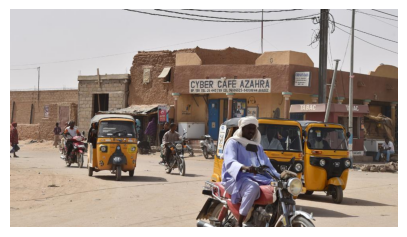

In [5]:
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

Experiment 5 - Structured Output

In [6]:
prompt="""
Return ONLY JSON
{
  "caption":"",
  "objects":[],
  "environment":"",
  "confidence":""
}
"""
output=ask_qwen_image(img_path, prompt)
print(output)

```json
{
"caption": "A busy street scene in a town, featuring several yellow auto-rickshaws (tuk-tuks) and motorcyclists navigating the dusty road. In the background is a building with signs for 'CYBER CAFE AZAHRA' and 'TABAC', set against an arid landscape under a bright sky.",
"objects":[
  "auto rickshaw",
  "motorcycle",
  "person",
  "building


Experiment 6 - Batch Dataset

In [ ]:
images=["../img/sample1.jpg", "../img/sample2.png", "../img/sample6.jpeg"]
results=[]

for img in images:
    out = ask_qwen_image(img, "describe image")
    results.append(
        {
            "image":img,
            "result":out
        }
    )


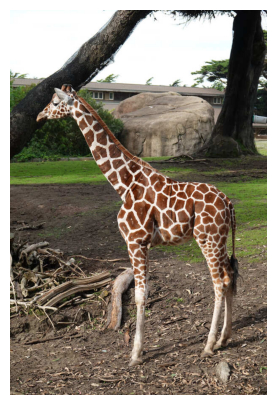

../img/sample1.jpg
This is a full-length, side-profile photograph of an adult giraffe standing in what appears to be a zoo or wildlife park enclosure. The giraffe has the classic reticulated pattern — large, polygonal brown patches separated by lighter cream-colored lines across its body and neck. Its ossicones (horn-like structures) are visible on top of its head, which is turned slightly toward the left of the frame.

The background includes:
- A large, dark tree trunk leaning diagonally from the upper right to the lower left.
- Another thick tree trunk standing upright behind the giraffe’s rear.
- A massive artificial rock formation in the mid-background.
- Green grass and dirt ground with scattered dry branches and logs near the foreground — possibly for enrichment or feeding purposes.
- In the far background, a building with windows suggests this is a managed facility like a zoo.

The lighting is bright and even, likely natural daylight under an overcast sky, casting soft shadows 

In [15]:
img = Image.open(results[0]['image'])

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

print(results[0]['image'])
print(results[0]['result'])

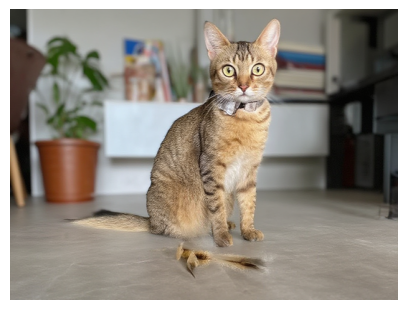

../img/sample2.png
This is a charming, well-lit indoor photograph featuring an elegant tabby cat as the central subject. The cat — likely a Siamese or similar breed with striking green eyes and fine golden-brown fur marked by dark stripes — sits upright on a smooth, light-colored floor (possibly concrete or polished stone). It wears a stylish gray polka-dot bowtie around its neck, adding a touch of personality and flair to its appearance.

The cat’s expression is alert and curious; it gazes directly at the camera with wide, bright eyes that catch the ambient light. Its posture is poised and attentive — front paws planted firmly, tail resting behind in a relaxed curve. Scattered near its feet are two small, feather-like objects — perhaps toy feathers or dried grass tufts — suggesting playful interaction just before this moment was captured.

The background softly blurs out of focus (shallow depth of field), drawing attention to the cat while still revealing key elements:
- To the left: 

In [14]:
img = Image.open(results[1]['image'])

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

print(results[1]['image'])
print(results[1]['result'])

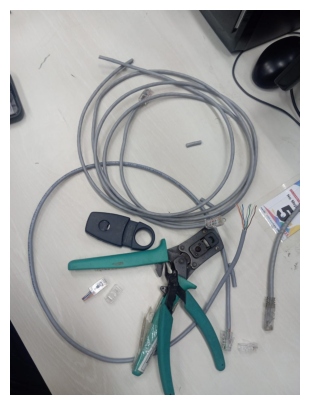

../img/sample6.jpeg
This is a photo of network cabling tools and materials laid out on a light-colored, possibly white or off-white, desk surface. The scene suggests someone is in the process of working with Ethernet cables — likely preparing to terminate them into RJ45 connectors for networking equipment like switches or routers.

Here’s a breakdown of what you can see:

### Tools & Equipment:
- **Two cable strippers/cutters**: 
  - One has green handles and appears to be a multi-tool (possibly combining stripper, cutter, and crimp tool functions). It’s partially open, as if recently used or being set up.
  - Another black-handled tool lies nearby — this is likely an insulated wire stripper designed for thicker outer sheath removal without damaging internal wires.

- **RJ45 connectors**: Several clear plastic Ethernet connectors are visible on the table and still in their protective packaging (some wrapped in green tape). These will be crimped onto the ends of the cables to create “pl

In [16]:
img = Image.open(results[2]['image'])

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

print(results[2]['image'])
print(results[2]['result'])